In [11]:
import healpy as hp
import numpy as np

import matplotlib.pyplot as plt

from astropy.io import fits

/tmp/ipykernel_392174/1779303207.py:1: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  mask = hp.read_map('/home/guerrini/data/CFIS/v1.0/Lensfit/masks/CFIS3500_THELI_mask_hp_8192.fits.gz', verbose=False)


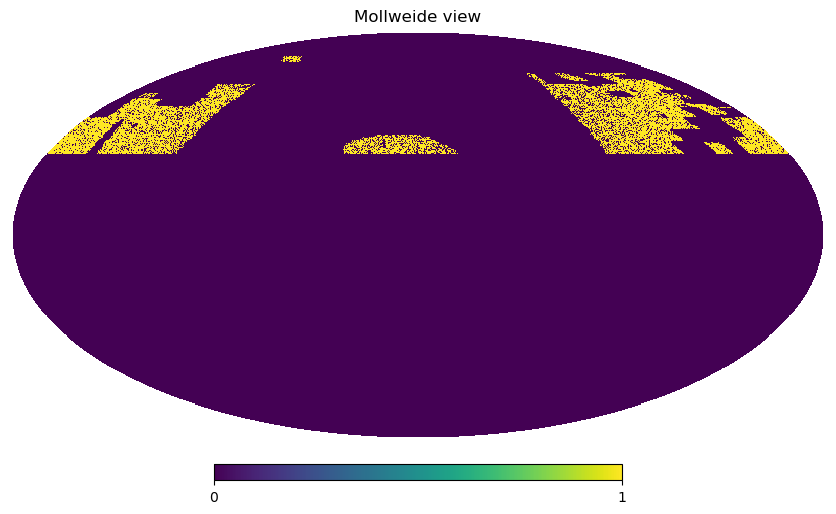

In [31]:
mask = hp.read_map('/home/guerrini/data/CFIS/v1.0/Lensfit/masks/CFIS3500_THELI_mask_hp_8192.fits.gz', verbose=False)

mask[mask==1]=16384
mask[mask==0]=1
mask[mask!=1]=0

hp.mollview(mask, cbar=True)
plt.show()

In [32]:
galaxies = fits.getdata('/home/guerrini/data/CFIS/v1.0/ShapePipe/unions_shapepipe_star_2022_v1.3.fits')

nside = hp.get_nside(mask)

galaxy_pixels = hp.ang2pix(nside, galaxies['ra'], galaxies['dec'], lonlat=True)

masked_galaxies = galaxies[mask[galaxy_pixels]!=0]

In [33]:
theta = 0.5 * np.pi - np.radians(masked_galaxies['DEC'])
phi = np.radians(masked_galaxies['RA'])
pix_indices = hp.ang2pix(nside, theta, phi, nest=False, lonlat=False)

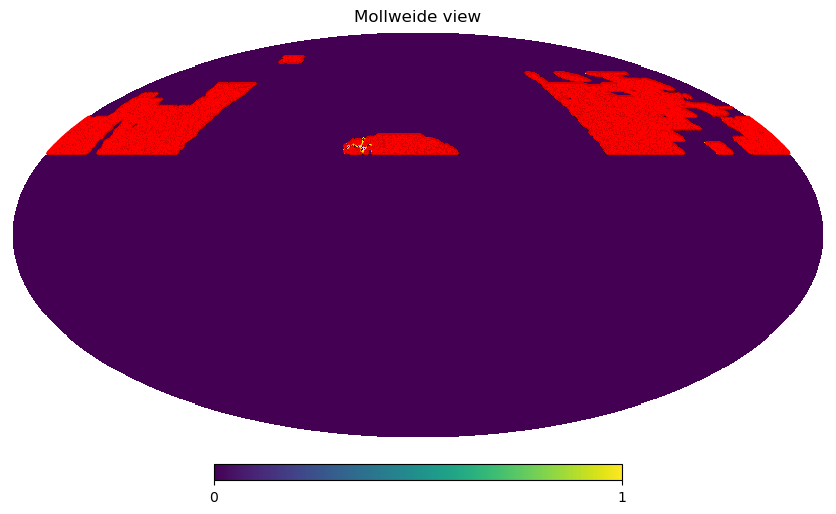

In [41]:
hp.mollview(mask)
hp.projscatter(theta, phi, color='r', s=0.001, alpha=0.5)

plt.show()

In [47]:
fits.writeto('/home/guerrini/data/unions_shapepipe_star_2022_v1.3_mtheli8k.fits', masked_galaxies)

OSError: File /home/guerrini/data/unions_shapepipe_star_2022_v1.3_mtheli8k.fits already exists. If you mean to replace it then use the argument "overwrite=True".

In [43]:
len(galaxies)

5293650